In [1]:
import pandas as pd

In [2]:
# import the file "FV CW podcasts.csv" to a dataframe
df = pd.read_csv("FV CW podcasts.csv")
df

,category,label,agent,text,text_coref,segmentation,episode,podcast,pod_cat,language,ClaimBuster,ClaimBuster COREF,Motivation,ClaimSpan
0,Checkworthy,Cause and Effect,Adam,Have you got a single company or a small busin...,NaN,spaCy,FBI Caught Red-Handed Retaliating Against Whis...,Verdict with Ted Cruz,politics,en,0.063155,NaN,NaN,NaN
1,Checkworthy,Cause and Effect,Adam,Have you got a single company or a small busin...,NaN,CW/MOT ALL,FBI Caught Red-Handed Retaliating Against Whis...,Verdict with Ted Cruz,politics,en,0.063155,NaN,NaN,NaN
2,Not Checkworthy,Emotions and Opinions,Adam,We're so happy you've joined us.,NaN,CW/MOT ALL,190: Man's Best Microbiome Buddy—How Dogs Bene...,Ancient Health Podcast,health,en,0.026074,NaN,NaN,NaN
3,Checkworthy,Factual Descriptions,Adam,This is his first podcast.,today's episode is a special guest's first pod...,CW/MOT ALL,190: Man's Best Microbiome Buddy—How Dogs Bene...,Ancient Health Podcast,health,en,0.235310,0.270269,Confirm True,"[{""start"":0,""end"":26}]"
4,Not Checkworthy,Emotions and Opinions,Adam,He might be a little bit nervous.,a special guest might be a little bit nervous.,CW/MOT ALL,190: Man's Best Microbiome Buddy—How Dogs Bene...,Ancient Health Podcast,health,en,0.085248,0.058712,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4166,Checkworthy,Factual Descriptions,gautek,Offerene er mye mer 50-50.,NaN,Factiverse CW/MO/CS,Åpen: Er det på tide å vise bilder fra massesk...,Aftenpodden USA,politics,no,NaN,NaN,Learn More,NaN
4167,Not Checkworthy,Not a Claim,gautek,Like mange kvinner og menn,NaN,Factiverse CW/MO/CS,Åpen: Er det på tide å vise bilder fra massesk...,Aftenpodden USA,politics,no,NaN,NaN,NaN,NaN
4168,Not Checkworthy,Not a Claim,gautek,omtrent.,NaN,Factiverse CW/MO/CS,Åpen: Er det på tide å vise bilder fra massesk...,Aftenpodden USA,politics,no,NaN,NaN,NaN,NaN
4169,Not Checkworthy,Not a Claim,gautek,"Men ja, det de sier er en fellesnevner.",NaN,Factiverse CW/MO/CS,Åpen: Er det på tide å vise bilder fra massesk...,Aftenpodden USA,politics,no,NaN,NaN,NaN,NaN


In [3]:
# filter podcasts so only those with the first two letters of the "language" column are "en"
df_eng = df[df["language"].str[:2] == "en"]
df_eng

,category,label,agent,text,text_coref,segmentation,episode,podcast,pod_cat,language,ClaimBuster,ClaimBuster COREF,Motivation,ClaimSpan
0,Checkworthy,Cause and Effect,Adam,Have you got a single company or a small busin...,NaN,spaCy,FBI Caught Red-Handed Retaliating Against Whis...,Verdict with Ted Cruz,politics,en,0.063155,NaN,NaN,NaN
1,Checkworthy,Cause and Effect,Adam,Have you got a single company or a small busin...,NaN,CW/MOT ALL,FBI Caught Red-Handed Retaliating Against Whis...,Verdict with Ted Cruz,politics,en,0.063155,NaN,NaN,NaN
2,Not Checkworthy,Emotions and Opinions,Adam,We're so happy you've joined us.,NaN,CW/MOT ALL,190: Man's Best Microbiome Buddy—How Dogs Bene...,Ancient Health Podcast,health,en,0.026074,NaN,NaN,NaN
3,Checkworthy,Factual Descriptions,Adam,This is his first podcast.,today's episode is a special guest's first pod...,CW/MOT ALL,190: Man's Best Microbiome Buddy—How Dogs Bene...,Ancient Health Podcast,health,en,0.235310,0.270269,Confirm True,"[{""start"":0,""end"":26}]"
4,Not Checkworthy,Emotions and Opinions,Adam,He might be a little bit nervous.,a special guest might be a little bit nervous.,CW/MOT ALL,190: Man's Best Microbiome Buddy—How Dogs Bene...,Ancient Health Podcast,health,en,0.085248,0.058712,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2819,Not Checkworthy,Not a Claim,Ma,Medical examiner says that they're gonna go th...,the medical examiner says that they're gonna g...,Factiverse CW/MO/CS,Ep. 1720 - Is This The New George Floyd?,The Ben Shapiro Show,politics,en,0.642296,0.597500,Confirm True,NaN
2820,Not Checkworthy,Broadcast Details,Ma,"It doesn't mean murder, a homicide.",NaN,Factiverse CW/MO/CS,Ep. 1720 - Is This The New George Floyd?,The Ben Shapiro Show,politics,en,0.476730,NaN,NaN,NaN
2821,Not Checkworthy,Not a Claim,Ma,That's correct.,NaN,Factiverse CW/MO/CS,Ep. 1720 - Is This The New George Floyd?,The Ben Shapiro Show,politics,en,0.178700,NaN,NaN,NaN
2822,Not Checkworthy,Not a Claim,Ma,It's complicated.,NaN,Factiverse CW/MO/CS,Ep. 1720 - Is This The New George Floyd?,The Ben Shapiro Show,politics,en,0.235635,NaN,NaN,NaN


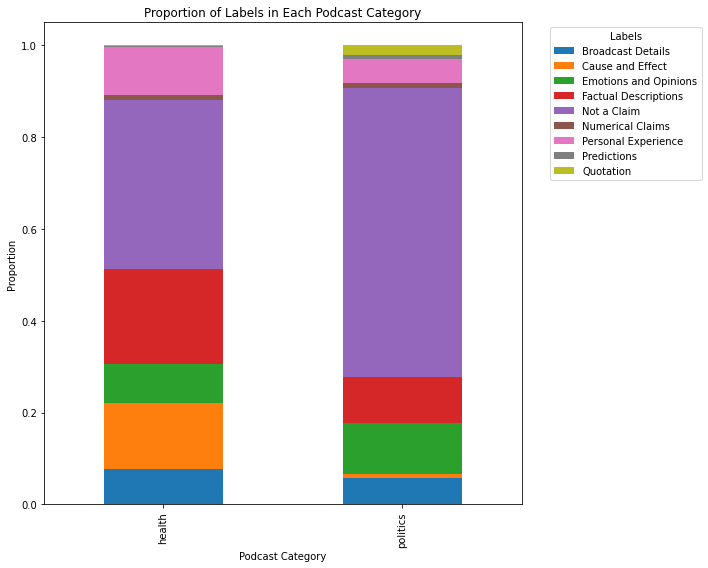

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Assume that df is your DataFrame
grouped = df.groupby('pod_cat')['label'].value_counts(normalize=True).rename('proportion').reset_index()

fig, ax = plt.subplots(figsize=(10,8))
grouped.pivot(index='pod_cat', columns='label', values='proportion').plot(kind='bar', stacked=True, ax=ax)
plt.title('Proportion of Labels in Each Podcast Category')
plt.xlabel('Podcast Category')
plt.ylabel('Proportion')
plt.legend(title='Labels', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


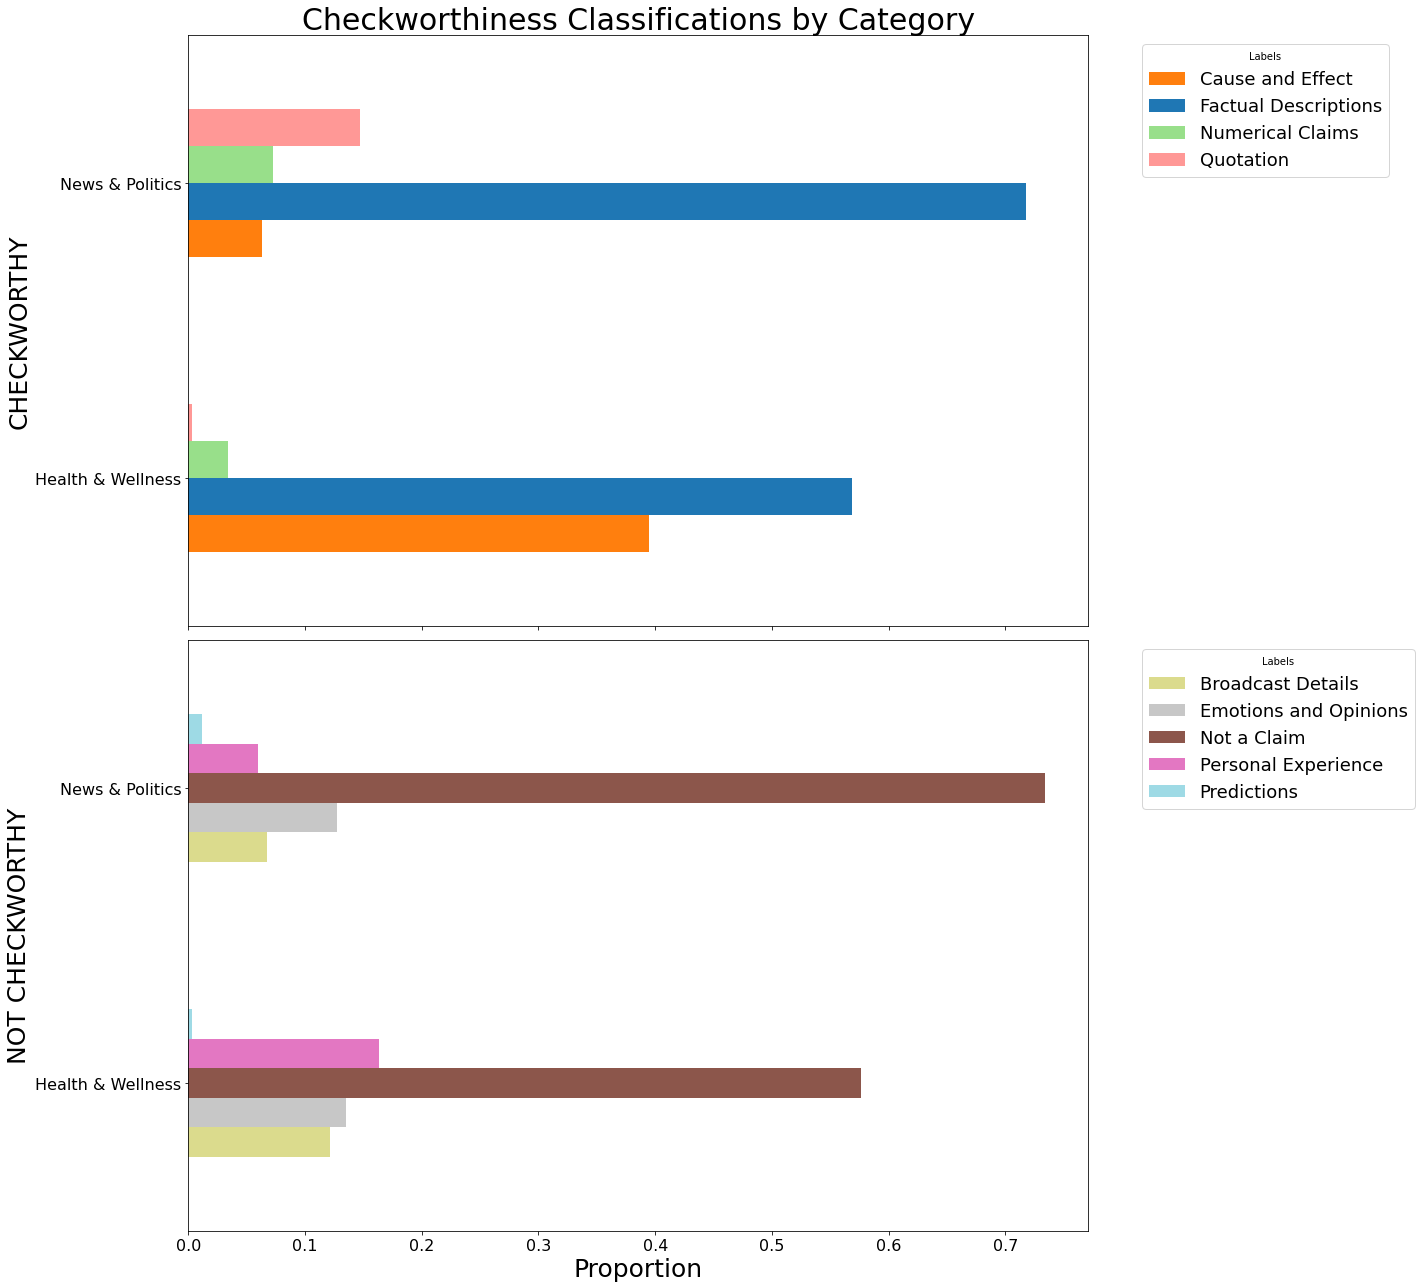

In [76]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np

# Assume that df is your DataFrame
df_checkworthy = df[df['category'] == 'Checkworthy'].replace("health", "Health & Wellness").replace("politics", "News & Politics")
df_not_checkworthy = df[df['category'] == 'Not Checkworthy'].replace("health", "Health & Wellness").replace("politics", "News & Politics")

grouped_checkworthy = df_checkworthy.groupby('pod_cat')['label'].value_counts(normalize=True).rename('proportion').reset_index()
grouped_not_checkworthy = df_not_checkworthy.groupby('pod_cat')['label'].value_counts(normalize=True).rename('proportion').reset_index()

# Get the list of unique labels in both dataframes
labels = pd.concat([grouped_checkworthy['label'], grouped_not_checkworthy['label']]).unique()

# Create a color map
colors = plt.get_cmap('tab20')(np.linspace(0, 1, len(labels)))
color_map = dict(zip(labels, colors))

fig, ax = plt.subplots(2, 1, figsize=(20,18), sharex=True)

pivot_checkworthy = grouped_checkworthy.pivot(index='pod_cat', columns='label', values='proportion')
pivot_not_checkworthy = grouped_not_checkworthy.pivot(index='pod_cat', columns='label', values='proportion')

pivot_checkworthy.plot(kind='barh', stacked=False, ax=ax[0], color=[color_map[i] for i in pivot_checkworthy.columns], fontsize=16)
ax[0].set_title('Checkworthiness Classifications by Category', size=30)
ax[0].set_ylabel('CHECKWORTHY', size=25)
ax[0].legend(title='Labels', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=18)

pivot_not_checkworthy.plot(kind='barh', stacked=False, ax=ax[1], color=[color_map[i] for i in pivot_not_checkworthy.columns], fontsize=16)
ax[1].set_xlabel('Proportion', size=25)
ax[1].set_ylabel('NOT CHECKWORTHY', size=25)
ax[1].legend(title='Labels', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=18)

plt.tight_layout()
plt.show()


<ipython-input-59-a3d40b2d407c>:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = plt.cm.get_cmap('tab20')


<Figure size 2160x1296 with 0 Axes>

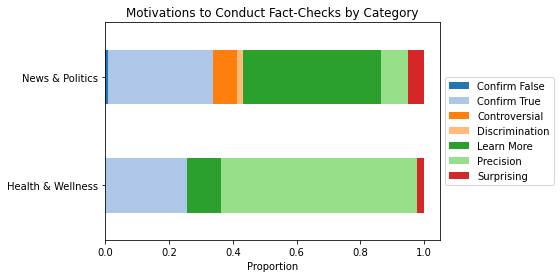

In [59]:
import matplotlib.pyplot as plt
import pandas as pd

# Creating a crosstab table
ct = pd.crosstab(df_checkworthy['pod_cat'].replace("health", "Health & Wellness").replace("politics", "News & Politics"), df_checkworthy['Motivation'])

# Calculating proportion
ct = ct.div(ct.sum(axis=1), axis=0)

# Create a color map
color_map = plt.cm.get_cmap('tab20')

# Set the figure size
plt.figure(figsize=(30, 18))  # Width: 10 inches, Height: 6 inches

# Plotting
ct.plot(kind='barh', stacked=True, color=[color_map(i) for i in range(len(ct.columns))])
plt.title('Motivations to Conduct Fact-Checks by Category')
plt.xlabel('Proportion')
plt.ylabel('')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) # move legend to the right outside of plot
plt.show()


In [6]:
df_eng.groupby(["category", "pod_cat", "label", "Motivation"]).size().unstack().apply(lambda x: x/x.sum(), axis=1)

Motivation                                      Confirm False  Confirm True   
category        pod_cat  label                                                
Checkworthy     health   Cause and Effect                 NaN      0.129032  \
                         Factual Descriptions             NaN      0.403509   
                         Numerical Claims                 NaN      0.428571   
                         Quotation                        NaN           NaN   
                politics Cause and Effect                 NaN      0.117647   
                         Factual Descriptions        0.011494      0.425287   
                         Numerical Claims                 NaN      0.166667   
                         Quotation                        NaN      0.270833   
Not Checkworthy health   Broadcast Details                NaN           NaN   
                politics Emotions and Opinions            NaN           NaN   
                         Not a Claim                      NaN      0.500000   

Motivation                                      Controversial  Discrimination   
category        pod_cat  label                                                  
Checkworthy     health   Cause and Effect                 NaN             NaN  \
                         Factual Descriptions             NaN             NaN   
                         Numerical Claims                 NaN             NaN   
                         Quotation                        NaN             NaN   
                politics Cause and Effect            0.294118             NaN   
                         Factual Descriptions        0.086207        0.005747   
                         Numerical Claims            0.083333             NaN   
                         Quotation                   0.125000        0.145833   
Not Checkworthy health   Broadcast Details                NaN             NaN   
                politics Emotions and Opinions       1.000000             NaN   
                         Not a Claim                      NaN             NaN   

Motivation                                      Gain Knowledge  Learn More   
category        pod_cat  label                                               
Checkworthy     health   Cause and Effect                  NaN    0.354839  \
                         Factual Descriptions              NaN    0.333333   
                         Numerical Claims                  NaN    0.428571   
                         Quotation                         NaN    1.000000   
                politics Cause and Effect                  NaN    0.411765   
                         Factual Descriptions              NaN    0.356322   
                         Numerical Claims                  NaN    0.500000   
                         Quotation                         NaN    0.333333   
Not Checkworthy health   Broadcast Details                 0.5         NaN   
                politics Emotions and Opinions             NaN         NaN   
                         Not a Claim                       NaN    0.250000   

Motivation                                      Precision  Surprising  
category        pod_cat  label                                         
Checkworthy     health   Cause and Effect        0.387097    0.129032  
                         Factual Descriptions    0.228070    0.035088  
                         Numerical Claims             NaN    0.142857  
                         Quotation                    NaN         NaN  
                politics Cause and Effect        0.117647    0.058824  
                         Factual Descriptions    0.045977    0.068966  
                         Numerical Claims             NaN    0.250000  
                         Quotation                    NaN    0.125000  
Not Checkworthy health   Broadcast Details            NaN    0.500000  
                politics Emotions and Opinions        NaN         NaN  
                         Not a Claim   

KeyError: 'Confirm False'

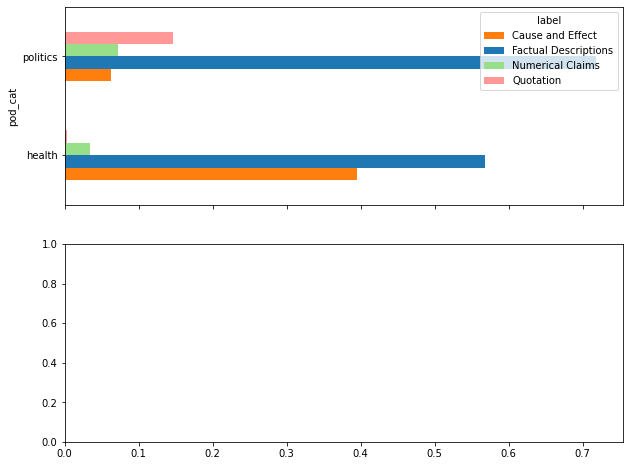

In [31]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np

# Assume that df is your DataFrame
df_checkworthy = df[df['category'] == 'Checkworthy']
df_not_checkworthy = df[df['category'] == 'Not Checkworthy']

grouped_checkworthy_label = df_checkworthy.groupby('pod_cat')['label'].value_counts(normalize=True).rename('proportion').reset_index()
grouped_checkworthy_motivation = df_checkworthy.groupby('pod_cat')['Motivation'].value_counts(normalize=True).rename('proportion').reset_index()

grouped_not_checkworthy = df_not_checkworthy.groupby('pod_cat')['label'].value_counts(normalize=True).rename('proportion').reset_index()

# Get the list of unique labels in both dataframes
labels = pd.concat([grouped_checkworthy_label['label'], grouped_not_checkworthy['label']]).unique()

# Create a color map
colors = plt.get_cmap('tab20')(np.linspace(0, 1, len(labels)))
color_map = dict(zip(labels, colors))

fig, ax = plt.subplots(2, 1, figsize=(10,8), sharex=True)

pivot_checkworthy_label = grouped_checkworthy_label.pivot(index='pod_cat', columns='label', values='proportion')
pivot_checkworthy_motivation = grouped_checkworthy_motivation.pivot(index='pod_cat', columns='Motivation', values='proportion')

pivot_checkworthy_label.plot(kind='barh', stacked=False, ax=ax[0], color=[color_map[i] for i in pivot_checkworthy_label.columns])
pivot_checkworthy_motivation.plot(kind='barh', stacked=False, ax=ax[0], color=[color_map[i] for i in pivot_checkworthy_motivation.columns])

ax[0].set_title('Checkworthy')
ax[0].set_xlabel('Proportion')
ax[0].legend(title='Labels & Motivation', bbox_to_anchor=(1.05, 1), loc='upper left')

pivot_not_checkworthy = grouped_not_checkworthy.pivot(index='pod_cat', columns='label', values='proportion')
pivot_not_checkworthy.plot(kind='barh', stacked=False, ax=ax[1], color=[color_map[i] for i in pivot_not_checkworthy.columns])

ax[1].set_title('Not Checkworthy')
ax[1].set_xlabel('Proportion')
ax[1].legend(title='Labels', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


<Axes: xlabel='pod_cat,category'>

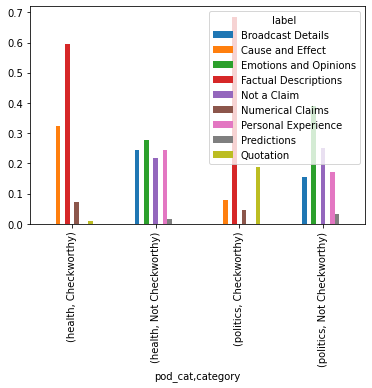

In [46]:
# make a bar graph with a group for each pod_cat (either "health" or "politics"), and within each group show a bar for the proportion of each unique label within that pod_cat group
# if any fields are NaN skip them
df_eng.groupby(["pod_cat", "category", "label"]).size().unstack().apply(lambda x: x/x.sum(), axis=1).plot.bar()


In [39]:
df_eng.groupby(["pod_cat", "category", "label"]).size().unstack().fillna(0).plot(kind="bar", stacked=True)

label                     Broadcast Details  Cause and Effect   
pod_cat  category                                               
health   Checkworthy                    NaN              31.0  \
         Not Checkworthy               30.0               NaN   
politics Checkworthy                    NaN              20.0   
         Not Checkworthy              102.0               NaN   

label                     Emotions and Opinions  Factual Descriptions   
pod_cat  category                                                       
health   Checkworthy                        NaN                  57.0  \
         Not Checkworthy                   34.0                   NaN   
politics Checkworthy                        NaN                 174.0   
         Not Checkworthy                  257.0                   NaN   

label                     Not a Claim  Numerical Claims  Personal Experience   
pod_cat  category                                                              
health   Checkworthy              NaN               7.0                  NaN  \
         Not Checkworthy         27.0               NaN                 30.0   
politics Checkworthy              NaN              12.0                  NaN   
         Not Checkworthy        165.0               NaN                112.0   

label                     Predictions  Quotation  
pod_cat  category                                 
health   Checkworthy              NaN        1.0  
         Not Checkworthy          2.0        NaN  
politics Checkworthy              NaN       48.0  
         Not Checkworthy         22.0        NaN

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='pod_cat,category'>

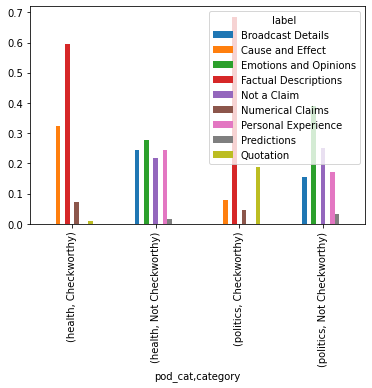

In [41]:
# make a bar graph with a group of columns for each possible value of pod_cat (either "health" or "politics"), 
# and within each of these groups show a bar for the PROPORTION of each unique label within that pod_cat group
# (i.e. the height of each bar is the proportion of podcasts in that pod_cat group that have that label)
df_eng.groupby(["pod_cat", "category", "label"]).size().unstack().fillna(0).apply(lambda x: x/x.sum(), axis=1).plot(kind="bar", stacked=False)


In [22]:
# Step 1: Groupby 'pod_cat' and 'label', and compute size of each group
grouped = df_eng.groupby(['pod_cat', 'label']).size()

# Step 2: Normalize the group sizes within each 'pod_cat' group
grouped_norm = grouped.groupby(level=0).apply(lambda x: x / x.sum())

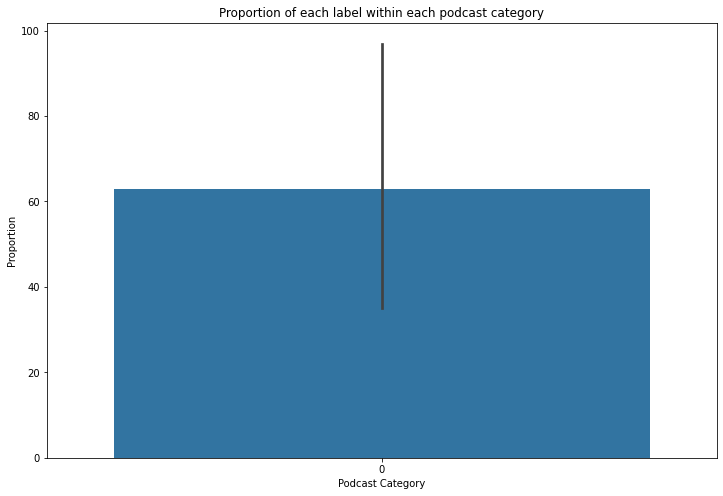

In [29]:
# Then, you can plot these proportions
plt.figure(figsize=(12, 8))
sns.barplot(data=grouped)
plt.title('Proportion of each label within each podcast category')
plt.ylabel('Proportion')
plt.xlabel('Podcast Category')

plt.show()

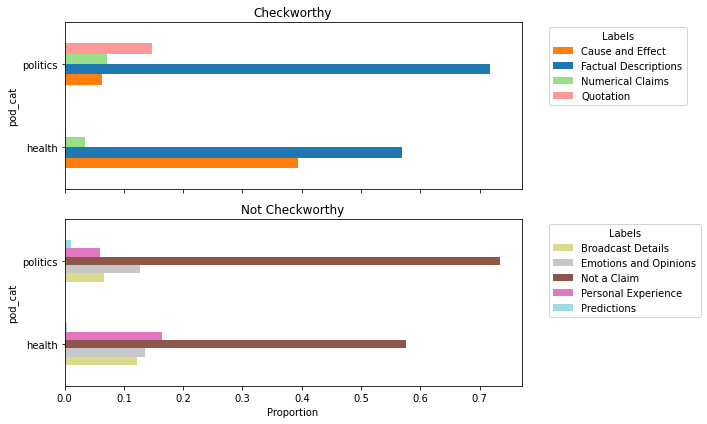

In [52]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np

# Assume that df is your DataFrame
df_checkworthy = df[df['category'] == 'Checkworthy']
df_not_checkworthy = df[df['category'] == 'Not Checkworthy']

grouped_checkworthy = df_checkworthy.groupby('pod_cat')['label'].value_counts(normalize=True).rename('proportion').reset_index()
grouped_not_checkworthy = df_not_checkworthy.groupby('pod_cat')['label'].value_counts(normalize=True).rename('proportion').reset_index()

# Get the list of unique labels in both dataframes
labels = pd.concat([grouped_checkworthy['label'], grouped_not_checkworthy['label']]).unique()

# Create a color map
colors = plt.get_cmap('tab20')(np.linspace(0, 1, len(labels)))
color_map = dict(zip(labels, colors))

fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

pivot_checkworthy = grouped_checkworthy.pivot(index='pod_cat', columns='label', values='proportion')
pivot_not_checkworthy = grouped_not_checkworthy.pivot(index='pod_cat', columns='label', values='proportion')

pivot_checkworthy.plot(kind='barh', stacked=False, ax=ax[0], color=[color_map[i] for i in pivot_checkworthy.columns])
ax[0].set_title('Checkworthy')
ax[0].set_xlabel('Proportion')
ax[0].legend(title='Labels', bbox_to_anchor=(1.05, 1), loc='upper left')

pivot_not_checkworthy.plot(kind='barh', stacked=False, ax=ax[1], color=[color_map[i] for i in pivot_not_checkworthy.columns])
ax[1].set_title('Not Checkworthy')
ax[1].set_xlabel('Proportion')
ax[1].legend(title='Labels', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
